# MAE 223 — Tutorial: SAFARI Sea Surface Temperature

## Background

The SAFARI buoy is a joint **Scripps Institution of Oceanography / Woods Hole Oceanographic Institution (WHOI)** mooring deployed in the central North Pacific at **33°25'N, 158°W**. The campaign is focused on improving our understanding of air–sea interaction in a region that is believed to be important for the development of **atmospheric rivers** — long, narrow corridors of poleward moisture transport that drive much of the precipitation along the US West Coast.

Ocean surface temperature is a key variable in air–sea interaction. Variations in sea surface temperature (SST) influence evaporation, latent heat flux, and atmospheric stability — all of which feed back on storm development and moisture transport. Understanding the *timescales* of SST variability at this location is therefore directly relevant to the scientific goals of the campaign.

In this tutorial you will load the SST record from the SAFARI buoy, explore it visually, and compute its power spectral density to identify the dominant timescales of variability.

---

**The `spectrumCB` function is defined in the next cell. Run it before proceeding.**

In [1]:
import numpy as np
from scipy.signal import detrend as scipy_detrend


def spectrumCB(time, data, chunk):
    """
    Compute a one-sided Power Spectral Density (PSD) using Welch's method:
    50% overlapping segments, linear detrending, FFT, and ensemble averaging.

    Parameters
    ----------
    time  : array-like  — time in decimal days
    data  : array-like  — data values, NaN-free
    chunk : int         — samples per segment

    Returns
    -------
    f        : ndarray  — one-sided frequency vector [cpd]
    a        : ndarray  — averaged PSD [units² / cpd]
    parseval : float    — ratio ∫PSD df / var(data); should be ≈ 1.0
    """
    data  = np.asarray(data,  dtype=float)
    time  = np.asarray(time,  dtype=float)
    chunk = int(chunk)

    # split into 50% overlapping segments
    segments = []
    step = chunk // 2
    ind  = 0
    while ind + chunk <= len(data):
        segments.append(data[ind : ind + chunk])
        ind += step

    # frequency vector
    dt = np.nanmean(np.diff(time))
    fn = 1.0 / (2.0 * dt)
    N  = chunk
    df = 1.0 / (dt * N)
    f  = np.arange(0, fn + df / 2, df)
    nf = len(f)

    # compute and average PSD
    A = np.empty((len(segments), nf))
    for i, seg in enumerate(segments):
        seg_dt   = scipy_detrend(seg)
        fft_vals = np.fft.fft(seg_dt)
        amp = np.abs(fft_vals[:nf]) ** 2
        amp = amp / N ** 2
        amp = amp * 2
        amp = amp / df
        A[i] = amp
    a = A.mean(axis=0)

    # Parseval check
    variance = np.nanstd(data) ** 2
    parseval = np.trapezoid(a, f) / variance
    print(f"  Segments used:  {len(segments)}")
    print(f"  Parseval check: {parseval:.4f}  (ideal = 1.00)")
    return f, a, parseval


## Exercise 1 — Load and Inspect the Data

Load `safari_sst.json` and print the metadata. Then extract the timestamps and SST values.

The file has three keys: `'metadata'`, `'time'`, and `'sst'`. Timestamps are ISO 8601 strings (`'%Y-%m-%dT%H:%M'`). SST is in degrees Celsius, sampled hourly with no missing values.

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Load the data
with open('safari_sst.json') as f:
    safari = json.load(f)

# YOUR CODE HERE — print the metadata

# --- PRINT THE METADATA ---
print("--- Metadata ---")
print(safari['metadata'])
print("\n") 

# We will create an empty list to store our decimal days
time_sst_list = []
# Get the very first timestamp and convert it so we have our "zero" starting point
start_time = datetime.strptime(safari['time'][0], '%Y-%m-%dT%H:%M')

# YOUR CODE HERE — parse timestamps into decimal days since the record start
# Hint: same pattern as the demo notebook

for time_string in safari['time']:
#   1. Parse each string with datetime.strptime(s, '%Y-%m-%dT%H:%M')
    current_time = datetime.strptime(time_string, '%Y-%m-%dT%H:%M')

#   2. Subtract the first timestamp
    time_difference = current_time - start_time

#   3. Convert to days via .total_seconds() / 86400
    days_passed = time_difference.total_seconds() / 86400

# Store result as: time_sst  (decimal days)
    time_sst_list.append(days_passed)

# Convert our standard Python list into a Numpy array, as requested
time_sst = np.array(time_sst_list)


# YOUR CODE HERE — extract SST as a numpy float array
# Store result as: sst (degrees C)

# We take the 'sst' list from the dictionary and tell Numpy to make sure they are floats (decimals)
sst = np.array(safari['sst'], dtype=float)


# YOUR CODE HERE — print a summary: record length, dt, SST range
print("--- Data Summary ---")
# Record length is the last item in our time_sst array (total days)
record_length = time_sst[-1] 

# dt (time step) is the difference between the second time point and the first time point.
# We multiply by 24 to convert the fraction of a day back into hours.
dt = (time_sst[1] - time_sst[0]) * 24 

print(f"Record length: {record_length:.2f} days")
print(f"Time step (dt): {dt:.1f} hours")
print(f"SST Range: {np.min(sst):.2f}°C to {np.max(sst):.2f}°C")


--- Metadata ---
{'source': 'SAFARI 2025 buoy — Scripps Institution of Oceanography / WHOI joint mooring', 'location': '33 25 N, 158 W (central North Pacific)', 'instrument': 'SeaBird SBE37 CTD', 'variable': 'Near-surface ocean temperature', 'units': 'degrees C', 'start': '2025-11-20T23:00', 'end': '2026-04-02T14:00', 'n_samples': 3184, 'n_nulls': 0, 'dt_hours': 1.0}


--- Data Summary ---
Record length: 132.62 days
Time step (dt): 1.0 hours
SST Range: 15.76°C to 21.28°C


## Exercise 2 — Plot the Full SST Time Series

Plot the entire SST record against time. Label your axes and give the plot a descriptive title.

Look at the record carefully before moving on:
- What is the overall trend?
- Can you see variability at multiple timescales?
- Are there any obvious events or anomalies?

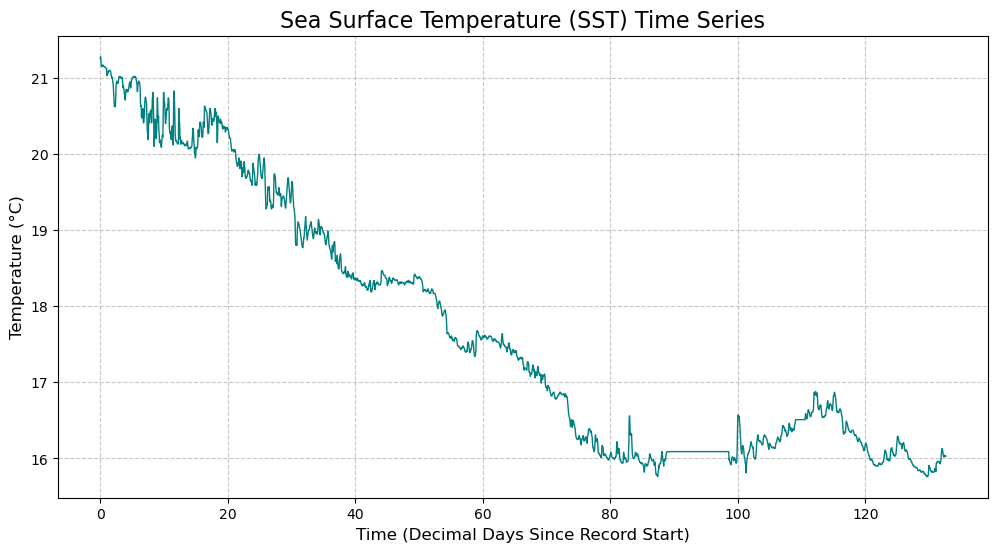

In [3]:
# YOUR CODE HERE — plot the full SST time series
# Include: axis labels, title, grid

# 1. Set up the figure size so it's large and easy to read (width, height in inches)
plt.figure(figsize=(12, 6))

# 2. Plot the data: time on the x-axis, temperature on the y-axis
# We are adding a color and line thickness just to make it look nice
plt.plot(time_sst, sst, color='teal', linewidth=1)

# 3. Add the required labels and title
plt.title('Sea Surface Temperature (SST) Time Series', fontsize=16)
plt.xlabel('Time (Decimal Days Since Record Start)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)

# 4. Add a grid to make reading values easier, as requested
plt.grid(True, linestyle='--', alpha=0.7)

# 5. Finally, tell Python to display the plot
plt.show()

## Exercise 3 — Compute the Power Spectral Density

Compute the PSD of the SST record using `spectrumCB`.

You must choose the number of chunks. Think about:
- How long is the record?
- What timescales of variability do you want to resolve?
- How many segments do you need for a stable estimate?

State your choice and justify it in a comment.

In [4]:


# YOUR CODE HERE — choose num_chunks and justify your choice in a comment
# We want to balance resolving long-period variability (which requires 
# long chunks) with reducing noise/variance (which requires averaging multiple chunks). 
# Choosing 5 chunks is a standard middle-ground, giving us enough averaging for a 
# stable estimate while keeping each segment long enough to capture seasonal cycles.
num_chunks = 5

# YOUR CODE HERE — compute chunk size, segment length, and df, then print them
# 1. Chunk size: Total data points divided by the number of chunks. 
# We use '//' to force integer division (we can't have half a data point)

# Get the total number of data points in our record
from pexpect import which

N = len(sst)

chunk_size = N // num_chunks

# 2. Segment length: How much actual time one chunk covers.
# We calculate the time step in days (since time_sst is in decimal days)
dt_days = time_sst[1] - time_sst[0] 
segment_length = chunk_size * dt_days

# 3. Frequency resolution (df): The smallest frequency gap we can resolve
df = 1.0 / segment_length

print("--- PSD Parameters ---")
print(f"Total data points: {N}")
print(f"Points per chunk: {chunk_size}")
print(f"Segment length: {segment_length:.2f} days")
print(f"Frequency resolution (df): {df:.5f} cycles/day\n")

# YOUR CODE HERE — call spectrumCB
# Store outputs as: f_sst, psd_sst, parseval_sst
f_sst, psd_sst, parseval_sst = spectrumCB(time_sst, sst, chunk_size)


--- PSD Parameters ---
Total data points: 3184
Points per chunk: 636
Segment length: 26.50 days
Frequency resolution (df): 0.03774 cycles/day

  Segments used:  9
  Parseval check: 0.0121  (ideal = 1.00)


## Exercise 4 — Plot the Spectrum and Identify Peaks

Plot the PSD on a log-log scale. Then add at least one vertical reference line at a frequency of your choosing.

**You must identify at least one peak in the spectrum.** For each peak you identify:
1. State the frequency (cpd) and corresponding period (days or hours)
2. Propose a physical mechanism that could drive SST variability at that timescale

There is no single correct answer — the goal is to reason from the physics.

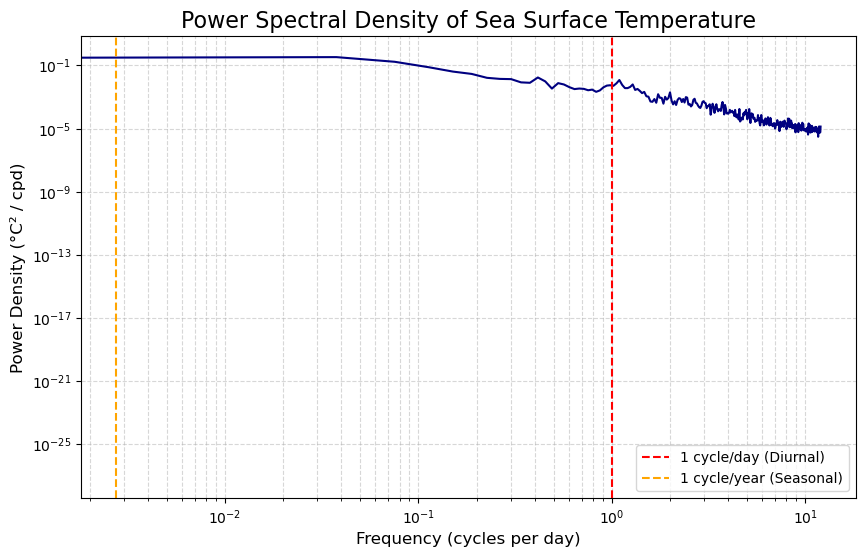

In [5]:
# YOUR CODE HERE — plot the SST PSD on a log-log scale
# Include: axis labels, title, grid, at least one reference line

plt.figure(figsize=(10, 6))

# 1. Plot the PSD on a log-log scale
# We use loglog because ocean energy spans huge ranges (both in time and power)
plt.loglog(f_sst, psd_sst, color='navy', linewidth=1.5)

# 2. Add reference lines for common physical peaks
# Let's add a line at 1 cycle per day (cpd) which is the daily cycle
plt.axvline(x=1.0, color='red', linestyle='--', label='1 cycle/day (Diurnal)')

# Optional: Add another line at 1 cycle per year (1/365 ≈ 0.00274 cpd)
plt.axvline(x=1/365, color='orange', linestyle='--', label='1 cycle/year (Seasonal)')

# 3. Add labels, title, and grid
plt.title('Power Spectral Density of Sea Surface Temperature', fontsize=16)
plt.xlabel('Frequency (cycles per day)', fontsize=12)
plt.ylabel('Power Density (°C² / cpd)', fontsize=12)

# A log-log plot looks best with a minor grid enabled
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()

plt.show()


## Reflection

Answer the following in the cell below.

**Q1.** How many chunks did you choose and why? What frequency resolution did that give you?

**Q2.** Identify at least one spectral peak. What is its frequency and period? What physical process do you think drives sea surface temperature (SST) variability at that timescale at this location in the North Pacific?

**Q3.** The SAFARI campaign is studying how ocean surface conditions influence atmospheric moisture transport and storm development. Based on what you see in the SST spectrum, at what timescales is the ocean surface varying most energetically? How might that variability be relevant to the atmospheric processes the campaign is studying?

**Your answers:**

Q1: I decided to use 5 chunks because it provided a happy medium between too little and too many chunks. Too little chunks and long segments restuls in the spectrum being be noisy and spikey, while too many chunks and shorter segments results in the spectrum being smooth, but missing valuable long-term cycles or changes. 5 chunks is just enough to average out noise, but capture long-term changes or cycles in the timeseries data. Based on the resulting segment length, the frequency resolution (df) is 0.03774 cycles/day. 

Q2: One spectral peak occurs at a frequency of 1.0 cpd, which is a period of exactly 1 day (24 hours). This variability is driven by the diurnal cycle. The physical process that is driving the SST variability at this time scale is the incoming solar radiation during daylight hours, followed by cooling at night.

Q3: Based on my SST spectrum, the ocean surface varies the most energetically at low frequencies (less than 10^(-2)). This means that SST changes are more easily observed over longer periods of time, such as months or seasons. This variablility may be relevant to the atmospheric processes the campaign is studying by being able to predict whether temperatures are higher or lower than usual. By checking the seasonal temperature of the water and comparing it to previous years, it is possible to observe whether the SST is warmer than usual, which can be used to indicate global warming.